# BDM vs. CTF: Two Lenses on the Same Signal

## Part of the open_dvm Toolbox

This tutorial brings together the two decoding frameworks covered separately in `05_bdm_decoding.ipynb`/`06_bdm_advanced.ipynb` (BDM) and `07_ctf_analysis.ipynb`/`08_ctf_advanced.ipynb` (CTF) to answer the **same question** with both, and compare what each one actually tells you.

**The question**: does the neural code that represents the *current* stimulus's location also carry information about *where the target was on the previous trial*? This is a classic inter-trial-priming question -- if spatial attention or working memory persists across trials, a decoder trained on the current stimulus's location might still pick up a trace of the previous trial's target location.

**Why use both BDM and CTF for the same question?**
- **BDM is a black box.** It tells you *whether* a linear classifier can distinguish trials by a label -- a single accuracy/AUC number per timepoint. If decoding is above chance, something in the signal correlates with that label. It does **not** tell you *what* that something is: it could be a genuine spatially-tuned memory trace, or an entirely non-spatial signal (e.g. residual motor preparation) that happens to correlate with location.
- **CTF is an interpretable, model-based alternative.** Because it fits a spatial encoding model and reconstructs a channel-tuning profile, a real spatial effect shows up as a *graded, location-tuned* reconstruction -- a shape you can look at, not just a number.

This notebook runs the **same cross-task analysis** through both methods -- train on localizer trials (which sample all 8 stimulus positions), test on main-task trials scored against the **previous** trial's target location -- using the `special_col` (BDM) / `special_loc` (CTF) parameters added specifically for this kind of trial-history analysis.

## Learning Objectives

After completing this tutorial, you will:

- **Use `special_col`/`special_loc` for trial-history analyses** -- override the test-set label with a different behavioral column (here, `prev_target_loc`) without touching the training data or your own dataframe
- **Compare BDM and CTF on identical data** -- same subjects, same train/test split, same underlying spatial variable
- **Interpret decodability vs. interpretability** -- see concretely why an above-chance BDM result and a graded CTF reconstruction support different strength conclusions

**Prerequisites:** This tutorial assumes familiarity with `05_bdm_decoding.ipynb` and `07_ctf_analysis.ipynb`, in particular the `cnds` cross-condition (train/test) syntax used there.

## Overview

### Key Steps
1. **Group-level BDM**: train on localizer `img_loc`, test on main-task trials scored against `prev_target_loc`, across all 7 subjects
2. **Group-level CTF**: the identical cross-task setup, reconstructing a spatial tuning profile instead of a single accuracy score
3. **Compare**: what each method's result does (and doesn't) let you conclude

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from matplotlib import gridspec
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import BDM, CTF
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_bdm_timecourse, plot_ctf_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Configuration

In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Eye-tracking quality control (same settings as 05/07)
eye_dict = {
    'use_tracker': True,     # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,      # Threshold: 1 degree visual angle
    'viewing_dist': 70,     # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,         # Screen height (cm)
    'drift_correct': (-0.2, 0)   # Drift correction window
}

print("✓ Configuration set")

✓ Configuration set


---

## Section 2: Group-Level BDM -- Decoding the Previous Target's Location

**Research Question**: Does a decoder trained to classify the *current* stimulus's location (from the localizer task, which samples all 8 positions) carry information about the **previous** trial's target location when applied to main-task trials?

**Approach**: For each subject, train a BDM decoder on localizer `img_loc` and test it on main-task trials, using `special_col='prev_target_loc'` to relabel the test set with the previous trial's target location instead of the current trial's. Trials where the previous trial had no target (`prev_target_loc == 8`) are excluded, leaving the 4 real target positions (0, 2, 4, 6). BDM's default metric is pairwise AUC (not raw accuracy), so chance performance stays at `0.5` regardless of the number of classes -- unlike accuracy, AUC's chance level doesn't scale with `1/n_classes`.

In [3]:
# Train on localizer, test on main task scored against the PREVIOUS trial's
# target location, for all subjects
print('Running cross-task BDM with special_col=\'prev_target_loc\' for all subjects...')
for subject_id in range(1, 8):
    try:
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            subject_id, 'ses_01_main', 'main', eye_dict
        )

        bdm = BDM(
            sj=subject_id, epochs=epochs_sj, df=df_sj,
            to_decode='img_loc',    # Same spatial variable CTF will reconstruct below
            baseline=(-0.2, 0),     # Baseline correction: -200 to 0 ms
            nr_folds=10,            # 10-fold cross-validation
            elec_oi='all',          # Use all electrodes
            data_type='raw',        # Time domain (not TF)
            downsample=128          # Downsample to 128 Hz
        )

        bdm.classify(
            cnds=dict(block_type=[['localizer'], ['main']]),  # Train on localizer, test on main
            window_oi=(-0.2, 0.5),           # Time window: -200 to 500 ms
            labels_oi=[0, 2, 4, 6],  # Only the 4 positions that occur as a main-task target
            excl_factor=dict(prev_target_loc=[8]),  # Drop trials with no previous target
            special_col='prev_target_loc',   # Score test trials against the PREVIOUS target's location
            f_name='bdm_prev_target'         # Analysis identifier for saved output
        )

        print(f'  ✓ Subject {subject_id} complete')
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed')

Running cross-task BDM with special_col='prev_target_loc' for all subjects...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
Dropped 1442 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

The difference between the highest and the lowest
number of observations per class is 3
Fold 1 out of 1 folds in run 1saving bdm scores
  ✓ Subject 1 complete
Reading /Use

Times converted from seconds to milliseconds
Using a threshold of 2.446912
stat_fun(H1): min=-2.3661053924464213 max=4.820721912163321
Running initial clustering …
Found 5 clusters


  0%|          | Permuting (exact test) : 0/63 [00:00<?,       ?it/s]

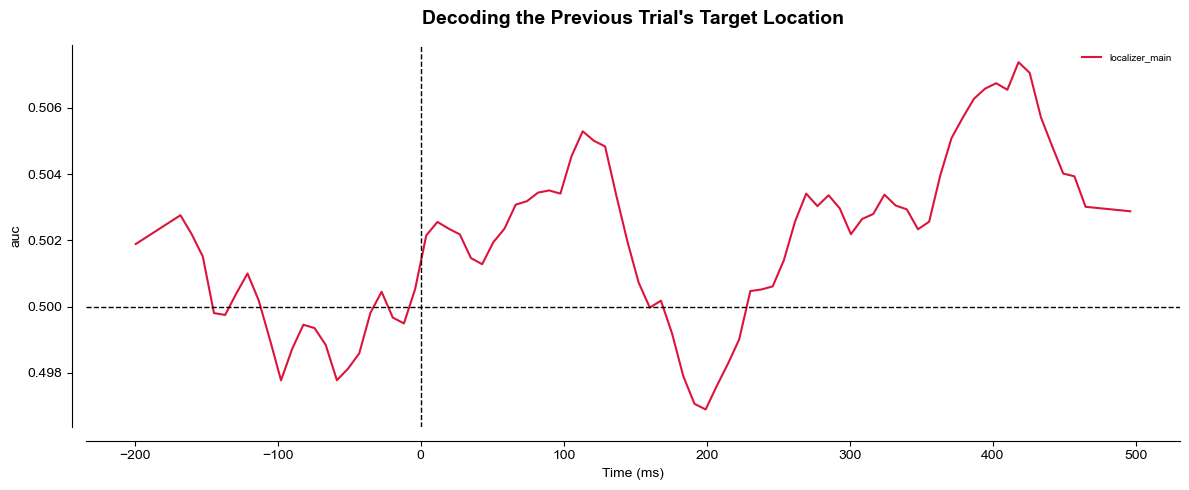

✓ Group-level BDM visualization complete


In [4]:
# Load per-subject results and visualize the group-level decoding timecourse
bdms_prev = FolderStructure().read_bdm(
    bdm_folder_path=['img_loc', 'all_elecs', 'cross'], bdm_name='bdm_prev_target', sjs='all'
)

fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    bdms_prev, cnds=['localizer_main'], chance_level=0.5,  # AUC chance level (metric='auc' default)
    stats='perm', colors=['crimson'], smooth=True  # cosmetic only -- stats run on raw data regardless
)
plt.title('Decoding the Previous Trial\'s Target Location', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Group-level BDM visualization complete")

### Interpretation

Whatever this timecourse shows -- above-chance decoding, or not -- it is the **only** thing BDM can tell you here: a single AUC value per timepoint, tested against chance (0.5). If decoding is significantly above 0.5, something in the signal distinguishes trials by the previous trial's target location. But BDM gives no indication of *what* that something is -- a genuine spatially-tuned memory trace and a non-spatial confound (e.g. residual response-related activity that happens to correlate with the previous location) would look identical in this plot.

---

## Section 3: Group-Level CTF -- Reconstructing *How* the Previous Target's Location Is Represented

**Research Question**: The identical cross-task setup as Section 2 -- but instead of a single accuracy number, can we reconstruct a spatial tuning profile for the previous trial's target location? A genuine spatial effect should show up as a *graded* reconstruction, peaking near the previous target's position and falling off with distance -- not just a yes/no signal.

**Approach**: Same train-on-localizer, test-on-main cross-task setup, using `special_loc='prev_target_loc'` (the CTF equivalent of BDM's `special_col`) to recenter test-trial reconstructions on the previous trial's target location instead of the current trial's.

In [5]:
# Train on localizer, test on main task, reconstructing tuning for the
# PREVIOUS trial's target location, for all subjects
print('Running cross-task CTF with special_loc=\'prev_target_loc\' for all subjects...')
for subject_id in range(1, 8):
    try:
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            subject_id, 'ses_01_main', 'main', eye_dict
        )

        ctf = CTF(
            sj=subject_id, epochs=epochs_sj, df=df_sj,
            to_decode='img_loc',   # Same spatial variable BDM decoded above
            nr_bins=8,             # 8 discrete position bins (matches 8 possible stimulus locations)
            nr_chans=8,            # 8 hypothetical spatial channels underlying the basis set
            elec_oi='all',         # Use all electrodes
            filter=8,              # Lowpass filter at 8 Hz for broadband voltage reconstruction
            avg_ch=True,           # Average tuning across bins (not per-bin reconstruction)
            baseline=(-0.2, 0),    # Baseline correction: -200 to 0 ms
            downsample=128         # Downsample to 128 Hz
        )

        ctf.spatial_ctf(
            pos_labels='all',                                 # Use all position bins
            cnds=dict(block_type=[['localizer'], ['main']]),  # Train on localizer, test on main
            window_oi=(-0.2, 0.5),           # Analysis window: -200 to 500 ms
            freqs='broadband',                # Broadband (unfiltered) voltage reconstruction
            excl_factor=dict(prev_target_loc=[8]),  # Drop trials with no previous target
            special_loc='prev_target_loc',    # Recenter test trials on the PREVIOUS target's location
            f_name='ctf_prev_target'          # Analysis identifier for saved output
        )

        print(f'  ✓ Subject {subject_id} complete')
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed')

Running cross-task CTF with special_loc='prev_target_loc' for all subjects...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
Creating bassiset with sin_power  7
Dropped 960 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuati

In [6]:
# Load per-subject results: raw reconstructions (for the 2D tuning heatmap)
# and parameters (for the slope timecourse)
ctfs_prev = FolderStructure().read_ctfs(
    ctf_folder_path=['img_loc'], output_type='ctf', ctf_name='ctf_prev_target', sjs='all'
)
ctf_params_prev = FolderStructure().read_ctfs(
    ctf_folder_path=['img_loc'], output_type='param', ctf_name='ctf_prev_target', sjs='all'
)

print("✓ Group-level CTF results loaded")

✓ Group-level CTF results loaded


Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
Using a threshold of 2.446912
stat_fun(H1): min=-2.7231853296461557 max=6.032505436880636
Running initial clustering …
Found 3 clusters


  0%|          | Permuting (exact test) : 0/63 [00:00<?,       ?it/s]

/var/folders/jd/_5gm34_n44x5fnp2_hdy7_1m0000gn/T/ipykernel_1971/2573994554.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


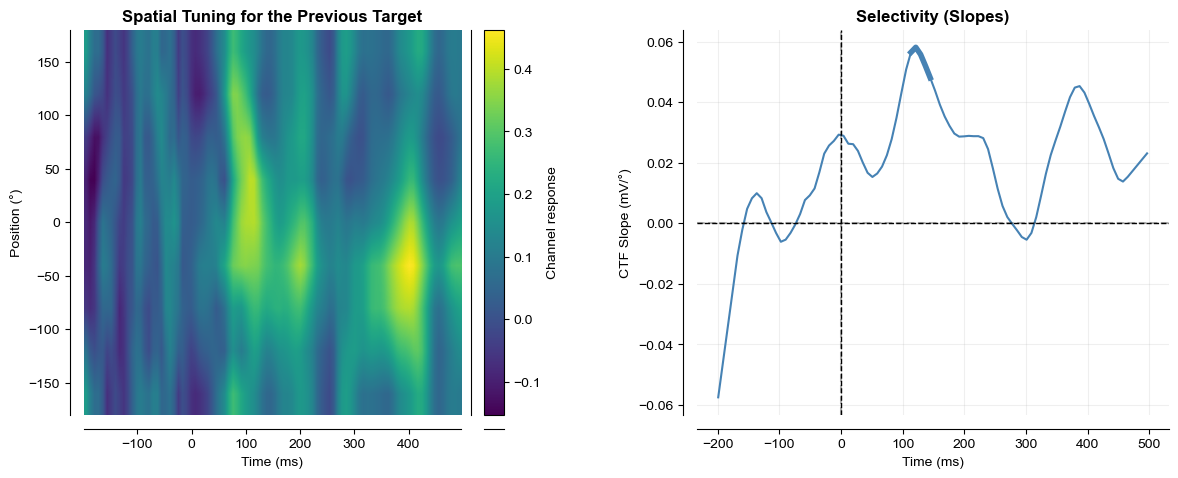

✓ Group-level CTF visualization complete


In [7]:
# Visualize: 2D spatial tuning (left) vs. slope timecourse (right)
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
plt.sca(ax1)
plot_ctf_timecourse(ctfs_prev, cnds=['localizer_main'], timecourse='2d_ctf',
                    output='C2_voltage', stats=None, smooth=True)
ax1.set_title('Spatial Tuning for the Previous Target', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Position (°)')

ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)
# stats='perm' to match Section 2's BDM test -- using the same cluster-based
# permutation test on both sides keeps the comparison fair; an uncorrected
# ttest here would be more liberal than BDM's test and could make CTF look
# more sensitive than BDM for reasons that have nothing to do with either
# method's actual sensitivity
plot_ctf_timecourse(ctf_params_prev, cnds=['localizer_main'], colors=['steelblue'],
                    output='voltage_slopes', stats='perm', smooth=True, show_legend=False)
ax2.set_title('Selectivity (Slopes)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('CTF Slope (mV/°)')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Group-level CTF visualization complete")

### Interpretation

The right-hand slope timecourse uses the same `stats='perm'` test as Section 2's BDM plot, so the two are directly comparable -- any difference in significance reflects the methods themselves, not a difference in how liberal the underlying test is.

If the two disagree -- e.g. a significant CTF slope where BDM showed nothing -- that's not necessarily a contradiction. CTF's slope statistic pools evidence across all spatial channels under the assumption that the response is *gradedly* tuned to position, while BDM's pairwise AUC treats every class independently and can't exploit that structure. For a genuinely graded but weak effect (plausible for a residual, one-trial-back memory trace), CTF's parametric assumption can buy real sensitivity that a classifier doesn't get for free. That would still be consistent with this notebook's core point: CTF's spatial model can do more than just add interpretability on top of an equally-sensitive test -- imposing the right structural assumption can also make weaker effects visible in the first place.

The left-hand panel is what BDM cannot give you regardless: if the reconstruction shows a **graded** profile -- amplitude peaking near 0° (the previous target's position, after recentering) and falling off with distance -- that is direct, visual evidence that the previous-target signal is genuinely spatially organized, not just some non-spatial pattern that a classifier could exploit.

---

## Section 4: Summary and Next Steps

This notebook ran the **identical cross-task analysis** -- train on localizer, test on main-task trials scored against the previous trial's target location -- through both decoding frameworks, using matched statistics (`stats='perm'`) so the two results are directly comparable:

1. ✅ **BDM (Section 2)**: a single accuracy-over-time curve. Answers *whether* the previous trial's target location can be decoded, nothing more.
2. ✅ **CTF (Section 3)**: a slope-over-time curve directly comparable to BDM's, plus a 2D spatial reconstruction that shows *what shape* the decodable information actually has.

**The takeaway**: BDM and CTF are complementary, not competing, tools. BDM's black-box accuracy score can't distinguish a genuine spatial effect from a non-spatial confound that happens to correlate with the label -- CTF's explicit spatial encoding model can. And because that model assumes and exploits a graded spatial structure, it can sometimes detect an effect that a classifier, which treats every class independently, misses entirely -- so don't be surprised if the two don't fully agree on significance. When they diverge, the 2D reconstruction is the tie-breaker: a graded, location-tuned profile is strong evidence for a genuine spatial code, regardless of what BDM alone would have concluded.

**Where to go next:**
- `05_bdm_decoding.ipynb` / `06_bdm_advanced.ipynb` -- the full BDM toolkit (GAT, TF-domain decoding, classifier comparisons)
- `07_ctf_analysis.ipynb` / `08_ctf_advanced.ipynb` -- the full CTF toolkit (frequency bands, von Mises fits, subject-specific reference-location alignment)